In [12]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
import seaborn as sns
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Custom functions (assumed in your local directory)
from fix_grid import fix_grid #
from useful_calculations import weighted_means
import pickle
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [2]:
###Load datasets
#ds_mom=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_monthly_0181-0190_noice_all.nc')
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc')
grid=xr.open_dataset(pathf+'ocean_grid.nc')

combined_mask_ctrl=xr.open_dataset(pathf+'categorization_simple.nc').corr_o2_stf_dic_stf
combined_mask_cc=xr.open_dataset(pathf+'categorization_simple_1PctTo2X.nc').corr_o2_stf_dic_stf_1PctTo2X

# violin

In [3]:
def masked_histogram_weighted(data_input, region_mask):
    """
    Compute area-weighted, clipped histogram for a masked region.
    Returns: histogram (density), bin_centers, total area fraction of the mask,
             weighted mean, weighted median.
    """
    # Clean weights
    area_clean = grid.area_t.fillna(0)
    
    # Boolean mask for the region
    mask_region = region_mask
    mask_broadcast = mask_region.broadcast_like(data_input)
    
    # Masked data and weights
    data_region = data_input.where(mask_region)
    weights_region = area_clean.broadcast_like(data_input).where(mask_broadcast).fillna(0)
    
    # Weighted mean and std
    weighted_da = data_region.weighted(weights_region)
    #mean = float(weighted_da.mean(skipna=True))
    std = float(weighted_da.std(skipna=True))
    
    # Normalize data for histogram
    da_norm = data_region / std
    
    # Flatten arrays for histogram and median

    #mask_region=mask_region.broadcast_like(data_input)
    #values = da_norm.values.flatten()
    #weights = weights_region.values.flatten()

    values=da_norm.where((da_norm.notnull())&(weights_region.notnull())&(weights_region>0))
    weights=weights_region.where((da_norm.notnull())&(weights_region.notnull())&(weights_region>0)).fillna(0)

    mean_norm=values.weighted(weights).mean(skipna=True)
    # Weighted median
    #median_norm = weighted_median(values, weights)
    #values_flat=values.values.flatten()
    #weights_flat = weights_region.broadcast_like(values).values.flatten()
    #valid_mask = np.isfinite(values_flat) & np.isfinite(weights_flat) & (weights_flat > 0)
#
    #values_valid = values_flat[valid_mask]
    #weights_valid = weights_flat[valid_mask]

    values = values.astype(float)
    weights = weights.astype(float)
    median_norm=values.weighted(weights).quantile(0.5)
    
    # Clip extremes for histogram

    #flatten
    values_flat = values.values.flatten()
    weights_flat = weights.values.flatten()
    
    valid_mask = np.isfinite(values_flat) & (weights_flat > 0)
    values_valid = values_flat[valid_mask]
    weights_valid = weights_flat[valid_mask]
    
    # Clip extremes for histogram
    values_clipped = np.clip(values_valid, -0.75, 0.75)
    
    #values_clipped = np.clip(values.values.flatten(), -0.75, 0.75)
    
    # Histogram
    hist, bins = np.histogram(
        values_clipped,
        bins=100,
        weights=weights_valid,
        density=False
    )
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Total area
    total_area = weights_region.sum()
    
    return  hist, bin_centers,total_area, mean_norm, median_norm 

In [6]:
def process_tracer_scenario(data_input, mask_input):
    """
    Processes a single tracer/scenario (e.g., CO2 Control).
    Returns a dictionary with all components and total stats.
    """
    results = {
        'comp_hists': [],  # Raw histograms
        'comp_pdfs': [],   # Area-weighted PDFs
        'means': [], 
        'medians': [], 
        'areas': [],
        'centers': None
    }
    
    # 1. Get raw histograms and areas for each region (1: Sol, 2: Prod, 3: Resp)
    for i in [1, 2, 3]:
        region_mask = (mask_input == i)
        # Assuming masked_histogram_weighted returns: hist, centers, area, mean, median
        h, centers, a, m, med = masked_histogram_weighted(data_input, region_mask)

        if results['centers'] is None:
            results['centers'] =centers
        
        results['comp_hists'].append(h)
        results['areas'].append(a.item())
        results['means'].append(m)
        results['medians'].append(med)
        
    # 2. Calculate Total Area for normalization
    total_area = sum(results['areas'])
    
    # 3. Apply your specific area-weighting normalization
    # hist_comp_pdf = hist_comp * (area_comp / total_area)
    for h, a in zip(results['comp_hists'], results['areas']):
        results['comp_pdfs'].append(h * (a / total_area))
        
    # 4. Create Total PDF (Sanity Check / Background)
    results['total_pdf'] = sum(results['comp_pdfs'])
    
    # 5. Get Total stats (Mean/Median for the whole mask 1-3)
    total_mask = (mask_input >= 1) & (mask_input <= 3)
    _, _, _, t_mean, t_med = masked_histogram_weighted(data_input, total_mask)
    results['total_mean'] = t_mean
    results['total_med'] = t_med
    
    return results

In [ ]:
# CO2 Data DON'T run again
co2_ctrl = process_tracer_scenario(dsa.dic_stf, combined_mask_ctrl)
co2_cc   = process_tracer_scenario(dsa.dic_stf_1PctTo2X, combined_mask_cc)

# O2 Data
o2_ctrl  = process_tracer_scenario(dsa.o2_stf, combined_mask_ctrl)
o2_cc    = process_tracer_scenario(dsa.o2_stf_1PctTo2X, combined_mask_cc)

In [ ]:
#saving
# Bundle everything into one master dictionary
all_results = {
    'co2_ctrl': co2_ctrl,
    'co2_cc': co2_cc,
    'o2_ctrl': o2_ctrl,
    'o2_cc': o2_cc,
    'bin_centers': co2_ctrl['centers'] # specifically saving this for the plot
}

# Save to a file
with open('histogram_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("Data saved successfully to histogram_results.pkl")

# plotting

In [3]:
# load data
with open('/gxfs_home/geomar/smomw577/mesoscale_eddies/plotting/histogram_results.pkl', 'rb') as f:
    all_results = pickle.load(f)

print("Data loaded successfully")

Data loaded successfully


In [4]:
co2_ctrl=all_results['co2_ctrl']
o2_ctrl=all_results['o2_ctrl']
co2_cc=all_results['co2_cc']
o2_cc=all_results['o2_cc']

In [5]:
#def darken_color(color, factor=0.7):
#    rgb = mcolors.to_rgb(color)
#    return tuple(factor * c for c in rgb)

def darken_color(color, factor=0.7):
    """
    Darken a color safely for matplotlib, works with hex or name,
    clamps values to [0,1].
    """
    import matplotlib.colors as mcolors
    # lowercase hex
    if isinstance(color, str) and color.startswith('#'):
        color = color.lower()
    # convert to RGB
    rgb = mcolors.to_rgb(color)
    # multiply and clamp
    dark_rgb = tuple(max(0, min(1, factor * c)) for c in rgb)
    return dark_rgb
    
def get_signed_edges(x_vals, y_vals, threshold=1e-6):
    """
    Returns (x_bottom, y_bottom), (x_top, y_top) for a curve,
    keeping the correct sign (negative for left, positive for right)
    """
    mask = np.abs(x_vals) > threshold
    if not np.any(mask):
        return None

    idxs = np.where(mask)[0]
    i_min, i_max = idxs[0], idxs[-1]

    return (x_vals[i_min], y_vals[i_min]), (x_vals[i_max], y_vals[i_max])
    
def draw_component_violin(ax, bin_centers, total_l, total_r, total_l_cc, total_r_cc, 
                          comp_l, comp_r, total_cc_l, total_cc_r, color, 
                          mean_l=None, mean_r=None, med_l=None, med_r=None,
                          mean_l_cc=None, mean_r_cc=None, med_l_cc=None, med_r_cc=None,
                          mean_total_l=None,mean_total_r=None, mean_total_l_cc=None,mean_total_r_cc=None,
                          median_total_l=None,median_total_r=None, median_total_l_cc=None,median_total_r_cc=None,title=""):
    width = 0.4
    
    # Normalize everything relative to the maximum of the TOTAL PDF
    max_val = max(total_l.max(), total_r.max())
    if max_val == 0: max_val = 1

    # --- 1. Draw Gray Background (Total) ---
    ax.fill_betweenx(bin_centers, -(total_l/max_val)*width, 0, color='gray', alpha=0.2, zorder=1)
    ax.fill_betweenx(bin_centers, 0, (total_r/max_val)*width, color='gray', alpha=0.2, zorder=1)
    
    # --- 2. Draw Gray Dashed Lines (Total CC Scenario) ---
    ax.plot(-(total_l_cc/max_val)*width, bin_centers, color=darken_color('gray', 0.5), linestyle='--', alpha=0.9, zorder=2, linewidth=0.9)
    ax.plot((total_r_cc/max_val)*width, bin_centers, color=darken_color('gray', 0.5), linestyle='--', alpha=0.9, zorder=2, linewidth=0.9)

    # --- 3. Draw Colored Component (Foreground) ---
    if comp_l is not None:
        ax.fill_betweenx(bin_centers, -(comp_l/max_val)*width, 0, color=color, alpha=0.4, zorder=3)
        ax.plot(-(total_cc_l/max_val)*width, bin_centers, color=darken_color(color, 0.7), linestyle='--', linewidth=1.2, zorder=4)
    if comp_r is not None:
        ax.fill_betweenx(bin_centers, 0, (comp_r/max_val)*width, color=color, alpha=0.4, zorder=3)
        ax.plot((total_cc_r/max_val)*width, bin_centers, color=darken_color(color, 0.7), linestyle='--', linewidth=1.2, zorder=4)
#
    # --- 4. Draw Mean (Dot) and Median (Line) ---
    # Left Side (CO2)
    if med_l is not None:
        ax.hlines(med_l, -0.15, 0,color=darken_color(color, 0.7), linewidth=1, zorder=5) # Median line
    if med_l_cc is not None:
        ax.hlines(med_l_cc,-0.15, 0,color=darken_color(color, 0.7), linewidth=1, zorder=5, linestyle='dashed') # Median line
    if mean_total_l is not None:
        ax.hlines(mean_total_l, -0.35, -0.15, color='black', linewidth=1, zorder=5) # Median line
    if mean_total_l_cc is not None:
        ax.hlines(mean_total_l_cc, -0.35, -0.15, color='black', linewidth=1, zorder=5, linestyle='dashed') # Median line


    if mean_l is not None:
        ax.scatter([-0.1], [mean_l], c=color, edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_l_cc is not None:
        ax.scatter([-0.1], [mean_l_cc], c=darken_color(color, 1.2), marker='D', edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_total_l is not None:
        ax.scatter([-0.2], [mean_total_l], c='gray', edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_total_l_cc is not None:
        ax.scatter([-0.2], [mean_total_l_cc], c=darken_color('gray', 1.2), marker='D', edgecolor='black', s=20, zorder=6) # Mean dot


#
    ## Right Side (O2)
    if med_r is not None:
        ax.hlines(med_r, 0, 0.15, color=darken_color(color, 0.7), linewidth=1, zorder=5) # Median line
    if med_r_cc is not None:
        ax.hlines(med_r_cc, 0, 0.15, color=darken_color(color, 0.7), linewidth=1, zorder=5, linestyle='dashed') # Median line
    if mean_total_r is not None:
        ax.hlines(mean_total_r, 0.15, 0.35, color='black', linewidth=1, zorder=5) # Median line
    if mean_total_r_cc is not None:
        ax.hlines(mean_total_r_cc, 0.15, 0.35, color='black', linewidth=1, zorder=5, linestyle='dashed') # Median line


    if mean_r is not None:
        ax.scatter([0.1], [mean_r], c=color, edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_r_cc is not None:
        ax.scatter([0.1], [mean_r_cc], c=darken_color(color, 1.2), marker='D', edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_total_r is not None:
        ax.scatter([0.2], [mean_total_r], c='gray', edgecolor='black', s=20, zorder=6) # Mean dot
    if mean_total_r_cc is not None:
        ax.scatter([0.2], [mean_total_r_cc], c=darken_color('gray', 1.2),marker='D',  edgecolor='black', s=20, zorder=6) # Mean dot

    # Styling
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
    ax.grid(which='minor', axis='x', linestyle=':')
    ax.grid(axis='y', linestyle=':')
    ax.axvline(0, color='k', linewidth=0.8, zorder=4)
    ax.set_title(title)
    #ax.set_xlim(-0.5, 0.5)
    #ax.set_ylim(-0.5, 0.5)
    ax.set_xticks([-0.25, 0.25])
    ax.set_xticklabels(["CO2", "O2"])

    #edge markers
    dy = 0.02 * (bin_centers.max() - bin_centers.min())
    
    all_curves = [
        (-(total_l/max_val)*width, bin_centers, 'gray', 'solid'),
        ((total_r/max_val)*width, bin_centers, 'gray', 'solid'),
        (-(total_l_cc/max_val)*width, bin_centers, darken_color('gray', 0.5), 'dashed'),
        ((total_r_cc/max_val)*width, bin_centers, darken_color('gray', 0.5), 'dashed'),
    ]
    
    if comp_l is not None:
        all_curves.append((-(comp_l/max_val)*width, bin_centers, color, 'solid'))
    if comp_r is not None:
        all_curves.append(((comp_r/max_val)*width, bin_centers, color, 'solid'))
    if total_cc_l is not None:
        all_curves.append((-(total_cc_l/max_val)*width, bin_centers, darken_color(color, 0.7), 'dashed'))
    if total_cc_r is not None:
        all_curves.append(((total_cc_r/max_val)*width, bin_centers, darken_color(color, 0.7), 'dashed'))

    extra = 0.03 * (bin_centers.max() - bin_centers.min())
    
    for x_vals, y_vals, col, linestyle in all_curves:
        edges = get_signed_edges(x_vals, y_vals)
        if edges is None:
            continuex_marker = x_b
        (x_bottom, y_bottom), (x_top, y_top) = edges
    
        # bottom marker
        ax.vlines(x_bottom, y_bottom - dy-extra, y_bottom + dy-0.02,
                  color=col, linewidth=1, zorder=7, linestyle=linestyle)
    
        # top marker
        ax.vlines(x_top, y_top - dy+0.02, y_top + dy +extra,
                  color=col, linewidth=1, zorder=7, linestyle=linestyle)

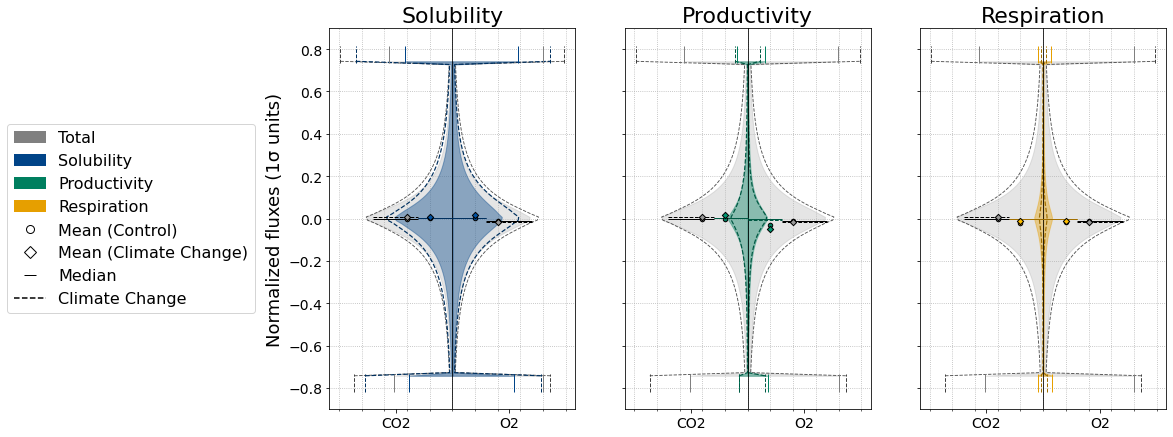

In [18]:
# Panels: 0: All, 1: Sol, 2: Prod, 3: Resp
# LEFT SIDE (CO2)
comp_l    = co2_ctrl['comp_pdfs']#[None] + 
comp_cc_l = co2_cc['comp_pdfs'] # Dash line [co2_cc['total_pdf']] + 
means_l   =  co2_ctrl['means']+ [co2_ctrl['total_mean']]
meds_l    = co2_ctrl['medians']+[co2_ctrl['total_med']] 
means_l_cc   = co2_cc['means']+[co2_cc['total_mean']] 
meds_l_cc    = co2_cc['medians']+[co2_cc['total_med']]


# RIGHT SIDE (O2)
comp_r    = o2_ctrl['comp_pdfs']#[None] + 
comp_cc_r = o2_cc['comp_pdfs'] # Dash line [o2_cc['total_pdf']] + 
means_r   = o2_ctrl['means']+[o2_ctrl['total_mean']]
meds_r    = o2_ctrl['medians']+[o2_ctrl['total_med']]
means_r_cc   = o2_cc['means']+[o2_cc['total_mean']]
meds_r_cc    = o2_cc['medians']+[o2_cc['total_med']]


bin_centers= co2_ctrl['centers']
colors = ["#004488","#007F5F","#e69f00"]
titles = ["Solubility", "Productivity", "Respiration"]

# Final Loop

fig, axes=plt.subplots(ncols=3, figsize=(15,7), sharey=True)
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})
for i, ax in enumerate(axes):
    draw_component_violin(
        ax, bin_centers, 
        co2_ctrl['total_pdf'], o2_ctrl['total_pdf'], # Gray backgrounds
        co2_cc['total_pdf'], co2_cc['total_pdf'],                       
        comp_l[i], comp_r[i], 
        comp_cc_l[i], comp_cc_r[i],
        # CC Dashed lines
        colors[i], 
        mean_l=means_l[i], mean_r=means_r[i],       # Stats
        med_l=meds_l[i], med_r=meds_r[i],
        mean_l_cc=means_l_cc[i], mean_r_cc=means_r_cc[i],       # Stats
        med_l_cc=meds_l_cc[i], med_r_cc=meds_r_cc[i],
        title=titles[i],
        
        mean_total_l=means_l[-1],
        mean_total_r=means_r[-1],
        mean_total_l_cc=means_l_cc[-1],
        mean_total_r_cc=means_r_cc[-1],

        median_total_l=meds_l[-1],
        median_total_r=meds_r[-1],
        median_total_l_cc=meds_l_cc[-1],
        median_total_r_cc=meds_r_cc[-1],
        
    )

legend_elements = [
        # Color patches
    Patch(facecolor='gray', label='Total'),
    Patch(facecolor='#004488', label='Solubility'),
    Patch(facecolor='#007F5F', label='Productivity'),
    Patch(facecolor='#e69f00', label='Respiration'),

    # Empty circle
    Line2D([0], [0], marker='o', color='black', markerfacecolor='none',
           markersize=8, linestyle='None', label='Mean (Control)'),
    # Empty diamond
    Line2D([0], [0], marker='D', color='black', markerfacecolor='none',
           markersize=8, linestyle='None', label='Mean (Climate Change)'),


    # Horizontal marker (underscore)
    Line2D([0], [0], marker='_', color='black',
           markersize=12, linestyle='None', label='Median'),

    # Dashed line
    Line2D([0], [0], color='black', linestyle='--', label='Climate Change')
]

axes[0].legend(handles=legend_elements, loc='center right', bbox_to_anchor=(-0.27, 0.5))
axes[0].set_ylabel("Normalized fluxes (1σ units)")
plt.savefig(pathp+'Violin.png',dpi=300, bbox_inches='tight')